In [2]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [3]:
import glob
import xarray as xr

PATH = "/Users/lb962/Documents/GitHub/ESL/data/ml_ready/*.nc"

# Get sorted list of files
files = sorted(glob.glob(PATH))

# Open each file into a list of datasets
datasets = [xr.open_dataset(f) for f in files]

# Example: inspect or process one
for i, ds in enumerate(datasets):
    print(f"File {i}: {files[i]}")
    print(ds)

# If you want them in memory:
datasets = [ds.load() for ds in datasets]


File 0: /Users/lb962/Documents/GitHub/ESL/data/ml_ready/small_ds.nc
<xarray.Dataset> Size: 438MB
Dimensions:            (station: 9, valid_time: 750192)
Coordinates:
  * station            (station) int64 72B 1 2 3 4 5 6 7 8 10
  * valid_time         (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-07...
    latitude           float64 8B ...
    longitude          float64 8B ...
    station_latitude   (station) float64 72B ...
    station_longitude  (station) float64 72B ...
Data variables: (12/14)
    u10                (station, valid_time) float32 27MB ...
    v10                (station, valid_time) float32 27MB ...
    d2m                (station, valid_time) float32 27MB ...
    t2m                (station, valid_time) float32 27MB ...
    msl                (station, valid_time) float32 27MB ...
    sst                (station, valid_time) float32 27MB ...
    ...                 ...
    mwd                (station, valid_time) float32 27MB ...
    mwp                (station

In [4]:
def preprocess(ds):
    return ds.sortby("station") 

datasets = [preprocess(xr.open_dataset(f)) for f in files]
ds = xr.concat(datasets, dim="station")

In [5]:
ds_recent = ds.where(ds["valid_time"].dt.year >= 2000, drop=True)

In [6]:
from numba import njit
import numpy as np
import xarray as xr
from numba import njit

@njit(cache=True, fastmath=True)
def _mask_1d(values, k_eff, mean, std, safe_lo, safe_hi,
             hard_clip_eff, p95, p95_margin_eff,
             q1, q3, use_quantiles, iqr_mult):
    n = values.shape[0]
    dev = np.zeros(n, dtype=np.bool_)
    last_kept = np.nan; have_last=False; prev_was_kept=False
    z_enabled = np.isfinite(std) and std > 0.0
    p95_gate = p95 + p95_margin_eff if np.isfinite(p95) else np.inf
    iqr = q3 - q1
    lo_iqr = q1 - iqr_mult * iqr
    hi_iqr = q3 + iqr_mult * iqr
    for i in range(n):
        x = values[i]
        if not np.isfinite(x): dev[i]=True; prev_was_kept=False; continue
        if np.abs(x) > hard_clip_eff: dev[i]=True; prev_was_kept=False; continue
        if (x >= safe_lo) and (x <= safe_hi): dev[i]=False; last_kept=x; have_last=True; prev_was_kept=True; continue
        if use_quantiles and ((x < lo_iqr) or (x > hi_iqr)): dev[i]=True; prev_was_kept=False; continue
        if z_enabled:
            z = (x - mean) / std
            if np.abs(z) > k_eff: dev[i]=True; prev_was_kept=False; continue
        if not prev_was_kept:
            if x <= p95_gate: dev[i]=False; last_kept=x; have_last=True; prev_was_kept=True
            else: dev[i]=True; prev_was_kept=False
            continue
        if have_last:
            allowed = 1.5 if (-1.0 <= last_kept <= 1.0) else 0.5
            if np.abs(x - last_kept) > allowed: dev[i]=True; prev_was_kept=False; continue
        dev[i]=False; last_kept=x; have_last=True; prev_was_kept=True
    return dev

# FAST block-drift mask: EW-quantile (median) + run-length
@njit(cache=True, fastmath=True)
def _block_mask_1d(values, med_thresh, min_run, alpha):
    n = values.shape[0]
    block = np.zeros(n, dtype=np.bool_)
    m = 0.0                        # EW median estimate (starts near 0 for residuals)
    run = 0                        # consecutive samples with |m| > threshold
    for i in range(n):
        x = values[i]
        if np.isfinite(x):
            # Robbins–Monro quantile update (tau=0.5 -> median)
            m += alpha * (0.5 - (1.0 if x < m else 0.0))
            if np.abs(m) > med_thresh:
                run += 1
                if run == min_run:
                    # backfill the initial block once threshold run is reached
                    start = i - min_run + 1
                    for j in range(start, i + 1):
                        block[j] = True
                elif run > min_run:
                    block[i] = True
            else:
                run = 0
        else:
            run = 0  # NaN breaks the block
    return block
@njit(cache=True, fastmath=True)
def _yrmean_block_mask_1d(values, yr_mean_vals, good_year_vals,
                          mean_abs_thresh, band, min_run):
    """
    Flag contiguous runs that stay near the (shifted) yearly mean, but only
    in years where |yearly mean| > mean_abs_thresh and coverage was 'good'.
    """
    n = values.shape[0]
    block = np.zeros(n, dtype=np.bool_)
    run = 0
    start = 0
    for i in range(n):
        x = values[i]
        if not np.isfinite(x):
            run = 0
            continue

        if not good_year_vals[i]:
            # year not eligible: reset run
            run = 0
            continue

        ymean = yr_mean_vals[i]
        if not np.isfinite(ymean) or (np.abs(ymean) <= mean_abs_thresh):
            # yearly mean not "shifted" enough
            run = 0
            continue

        # Are we "near" the shifted yearly mean?
        if np.abs(x - ymean) <= band:
            if run == 0:
                start = i
            run += 1
            if run == min_run:
                for j in range(start, i + 1):
                    block[j] = True
            elif run > min_run:
                block[i] = True
        else:
            run = 0
    return block
def filter_residual(
    ds: xr.Dataset,
    var: str = "residual",
    dim: str | None = None,
    base_k: float = 5.0,
    safe_keep_band: tuple[float, float] = (-2.0, 2.0),
    hard_clip: float = 3.0,
    p95_margin: float = 0.5,
    station_dim: str = "station",
    min_frac_year: float = 0.5,
    kurt_hard: float = 1.0,
    # mean-shift block knobs
    year_mean_abs_thresh: float = 1.0,   # consider a year "shifted" if |year mean| > 1 m
    block_band: float = 0.5,             # samples within ±band of the yearly mean count toward a block
    min_run: int = 60,                   # consecutive samples near the mean to declare a block
):
    da = ds[var]; dim = da.dims[0] if dim is None else dim
    ds = ds.sortby(dim); da = ds[var].astype("float64")

    # --- robust stats (unchanged)
    mu   = da.mean(dim=dim, skipna=True)
    sig  = da.std(dim=dim,  skipna=True)
    p95  = da.quantile(0.95, dim=dim, skipna=True)
    qs   = da.quantile([0.25, 0.75], dim=dim, skipna=True)
    q1, q3 = qs.sel(quantile=0.25), qs.sel(quantile=0.75)

    m2 = da.var(dim=dim, skipna=True)
    m4 = ((da - mu) ** 4).mean(dim=dim, skipna=True)
    ex_kurt = xr.where(m2 > 0, m4 / (m2 ** 2) - 3.0, 0.0)
    heavy = ex_kurt > kurt_hard

    k_eff          = xr.where(heavy, base_k / 2.5, base_k)
    iqr_mult       = xr.where(heavy, 1.0, 1.5)
    hard_clip_eff  = xr.where(heavy, 2.0, hard_clip)
    p95_margin_eff = xr.where(heavy, 0.1, p95_margin)
    use_quantiles  = heavy

    dev_point = xr.apply_ufunc(
        _mask_1d,
        da, k_eff, mu, sig,
        xr.DataArray(safe_keep_band[0]), xr.DataArray(safe_keep_band[1]),
        hard_clip_eff, p95, p95_margin_eff,
        q1, q3, use_quantiles, iqr_mult,
        input_core_dims=[[dim], [], [], [], [], [], [], [], [], [], [], [], []],
        output_core_dims=[[dim]],
        vectorize=True, dask="parallelized",
        output_dtypes=[bool],
    )

    # --- yearly mean and coverage (unchanged)
    present = da.notnull()
    cov_year = present.groupby(f"{dim}.year").mean(dim=dim)         # fraction present per year
    yr_mean  = da.groupby(f"{dim}.year").mean(dim=dim, skipna=True)  # mean per year
    good_year = cov_year > min_frac_year

    # --- NEW: broadcast per-year values back to each timestamp by selecting with a per-sample 'year' indexer
    # Ensure time axis is datetime64
    if not np.issubdtype(ds[dim].dtype, np.datetime64):
        # If your coord isn't datetime64, convert it here (one-time)
        ds = ds.assign_coords({dim: xr.converters.to_datetime64(ds[dim])})
        da = ds[var].astype("float64")

    year_indexer = xr.DataArray(
        ds[dim].dt.year,         # vector of years for every sample along `dim`
        dims=dim,
        coords={dim: ds[dim]}
    )

    # These now have the SAME dims as `da` (broadcasted back from 'year')
    yr_mean_full   = yr_mean.sel(year=year_indexer)
    good_year_full = good_year.sel(year=year_indexer)

    # --- block detector: runs near the shifted yearly mean
    dev_block = xr.apply_ufunc(
        _yrmean_block_mask_1d,
        da,
        yr_mean_full,
        good_year_full,
        xr.DataArray(year_mean_abs_thresh),
        xr.DataArray(block_band),
        xr.DataArray(np.int64(min_run)),
        input_core_dims=[[dim], [dim], [dim], [], [], []],
        output_core_dims=[[dim]],
        vectorize=True, dask="parallelized",
        output_dtypes=[bool],
    )

    deviant = dev_point | dev_block

    out = ds.copy()
    out[f"{var}_is_deviant"] = deviant
    out[var] = da.where(~deviant)

    if station_dim in out.dims:
        extra = [d for d in cov_year.dims if d not in (station_dim, "year")]
        cov_check = cov_year if not extra else cov_year.mean(dim=extra)
        keep_station = (cov_check > min_frac_year).any(dim="year")
        out = out.isel({station_dim: keep_station})

    return out, out[f"{var}_is_deviant"]
# ds: xr.Dataset with a variable named "residual" along dimension "time"
ds_filtered, dev_mask = filter_residual(ds_recent, var="residual", dim="valid_time")
ds = ds_filtered

/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/core/nputils.py:233: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/core/nputils.py:233: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


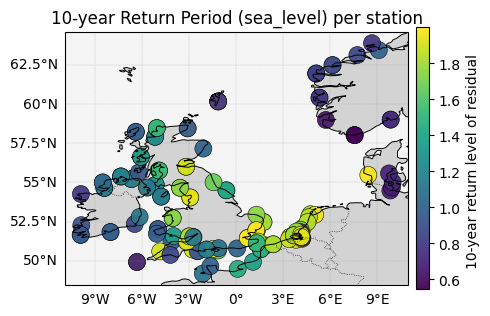

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1) Annual maxima of sea_level per station
annual_max = ds["residual"].groupby("valid_time.year").max("valid_time", skipna=True)  # (station, year)

# 2) Require at least 10 annual maxima to estimate a 10-yr RL
n_years = annual_max.notnull().sum("year")                                              # (station,)
tenyr_rl = annual_max.quantile(0.9, dim="year", skipna=True)                             # (station,)
tenyr_rl = tenyr_rl.where(n_years >= 3)                                                # mask weak stations

# 3) Pull station coords (1D over 'station')
lons = ds["station_longitude"].values
lats = ds["station_latitude"].values
vals = tenyr_rl.values

# Optional: units for colorbar label if present
units = ds["sea_level"].attrs.get("units", "")

# 4) Quick Cartopy plot
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(5, 4))
ax = plt.axes(projection=proj)

# Extent with padding from station points
valid = np.isfinite(lons) & np.isfinite(lats)
xmin, xmax = float(np.nanmin(lons[valid])), float(np.nanmax(lons[valid]))
ymin, ymax = float(np.nanmin(lats[valid])), float(np.nanmax(lats[valid]))
pad_x = max(0.5, 0.05 * (xmax - xmin))
pad_y = max(0.5, 0.05 * (ymax - ymin))
ax.set_extent([xmin - pad_x, xmax + pad_x, ymin - pad_y, ymax + pad_y], crs=proj)
#ax.set_extent([4.5, 10, 60, 65], crs=proj)

# Base features
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="whitesmoke")
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5, linestyle="--")
gl.right_labels = False
gl.top_labels = False

# 5) Plot stations (color = 10-yr return level)
sc = ax.scatter(
    lons, lats,
    c=vals, s=150, cmap="viridis",
    edgecolor="black", linewidth=0.4, alpha=0.95,
    transform=proj
)

cb = plt.colorbar(sc, ax=ax, fraction=0.036, pad=0.02)
cb.set_label(f"10-year return level of residual {f'({units})' if units else ''}")

ax.set_title("10-year Return Period (sea_level) per station")
plt.tight_layout()
plt.show()


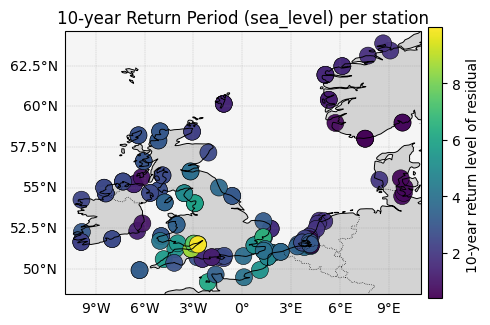

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1) Annual maxima of sea_level per station
annual_max = ds["sea_level"].groupby("valid_time.year").max("valid_time", skipna=True)  # (station, year)

# 2) Require at least 10 annual maxima to estimate a 10-yr RL
n_years = annual_max.notnull().sum("year")                                              # (station,)
tenyr_rl = annual_max.quantile(0.9, dim="year", skipna=True)                             # (station,)
tenyr_rl = tenyr_rl.where(n_years >= 3)                                                # mask weak stations

# 3) Pull station coords (1D over 'station')
lons = ds["station_longitude"].values
lats = ds["station_latitude"].values
vals = tenyr_rl.values

# Optional: units for colorbar label if present
units = ds["sea_level"].attrs.get("units", "")

# 4) Quick Cartopy plot
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(5, 4))
ax = plt.axes(projection=proj)

# Extent with padding from station points
valid = np.isfinite(lons) & np.isfinite(lats)
xmin, xmax = float(np.nanmin(lons[valid])), float(np.nanmax(lons[valid]))
ymin, ymax = float(np.nanmin(lats[valid])), float(np.nanmax(lats[valid]))
pad_x = max(0.5, 0.05 * (xmax - xmin))
pad_y = max(0.5, 0.05 * (ymax - ymin))
ax.set_extent([xmin - pad_x, xmax + pad_x, ymin - pad_y, ymax + pad_y], crs=proj)
#ax.set_extent([4.5, 10, 60, 65], crs=proj)

# Base features
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="whitesmoke")
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5, linestyle="--")
gl.right_labels = False
gl.top_labels = False

# 5) Plot stations (color = 10-yr return level)
sc = ax.scatter(
    lons, lats,
    c=vals, s=150, cmap="viridis",
    edgecolor="black", linewidth=0.4, alpha=0.95,
    transform=proj
)

cb = plt.colorbar(sc, ax=ax, fraction=0.036, pad=0.02)
cb.set_label(f"10-year return level of residual {f'({units})' if units else ''}")

ax.set_title("10-year Return Period (sea_level) per station")
plt.tight_layout()
plt.show()


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_99692/3822203036.py:10: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_total = ds.dims.get("station", ds["sea_level"].sizes.get("station"))


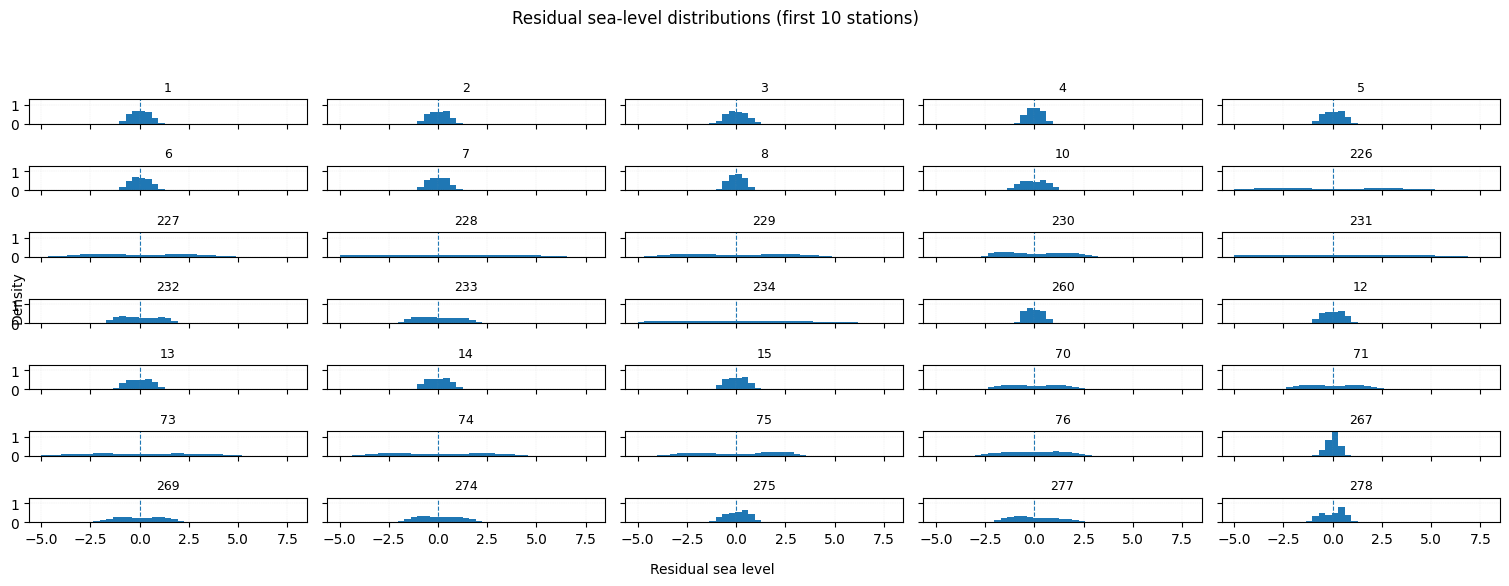

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

# --- Config ---
max_stations = 35
ncols = 5

# Slice the first N stations
n_total = ds.dims.get("station", ds["sea_level"].sizes.get("station"))
n = min(max_stations, n_total)
data = ds["sea_level"].isel(station=slice(0, n))  # (station, valid_time)

# Pull labels if available
def station_labels_from_ds(ds, n):
    candidates = ["station_name", "name", "station_id", "id", "station"]
    for key in candidates:
        if key in ds:
            try:
                return [str(v) for v in ds[key].isel(station=slice(0, n)).values]
            except Exception:
                pass
        if key in ds.coords:
            try:
                return [str(v) for v in ds.coords[key].isel(station=slice(0, n)).values]
            except Exception:
                pass
    return [f"Station {i}" for i in range(n)]

labels = station_labels_from_ds(ds, n)

# Units for axis label if present
units = ds["sea_level"].attrs.get("units", "")

# Compute common bins across all selected stations (ignoring NaNs)
vals_all = data.values  # shape: (station, time)
finite = np.isfinite(vals_all)
if not np.any(finite):
    raise ValueError("All values are NaN for the selected stations.")
vmin = float(np.nanmin(vals_all))
vmax = float(np.nanmax(vals_all))
# Guard against zero-width range
if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
    vmin, vmax = vmin - 0.5, vmax + 0.5
bins = np.linspace(vmin, vmax, 40)

# Figure layout
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 6), sharex=True, sharey=True)
if isinstance(axes, np.ndarray):
    axes = axes.ravel()
else:
    axes = [axes]

# Plot each station histogram
for i in range(n):
    ax = axes[i]
    arr = vals_all[i, :]
    arr = arr[np.isfinite(arr)]
    ax.hist(arr, bins=bins, density=True)
    ax.axvline(0.0, linestyle="--", linewidth=0.8)
    ax.set_title(labels[i], fontsize=9)
    ax.grid(alpha=0.3, linestyle="--", linewidth=0.3)

# Hide any unused subplots
for j in range(n, nrows * ncols):
    axes[j].axis("off")

# Labels and layout
fig.suptitle("Residual sea-level distributions (first 10 stations)", fontsize=12)
fig.text(0.5, 0.04, f"Residual sea level {f'({units})' if units else ''}", ha="center")
fig.text(0.06, 0.5, "Density", va="center", rotation="vertical")
plt.tight_layout(rect=[0.05, 0.06, 1, 0.94])
plt.show()

27 stations exceed 4.0 m 10-yr RL


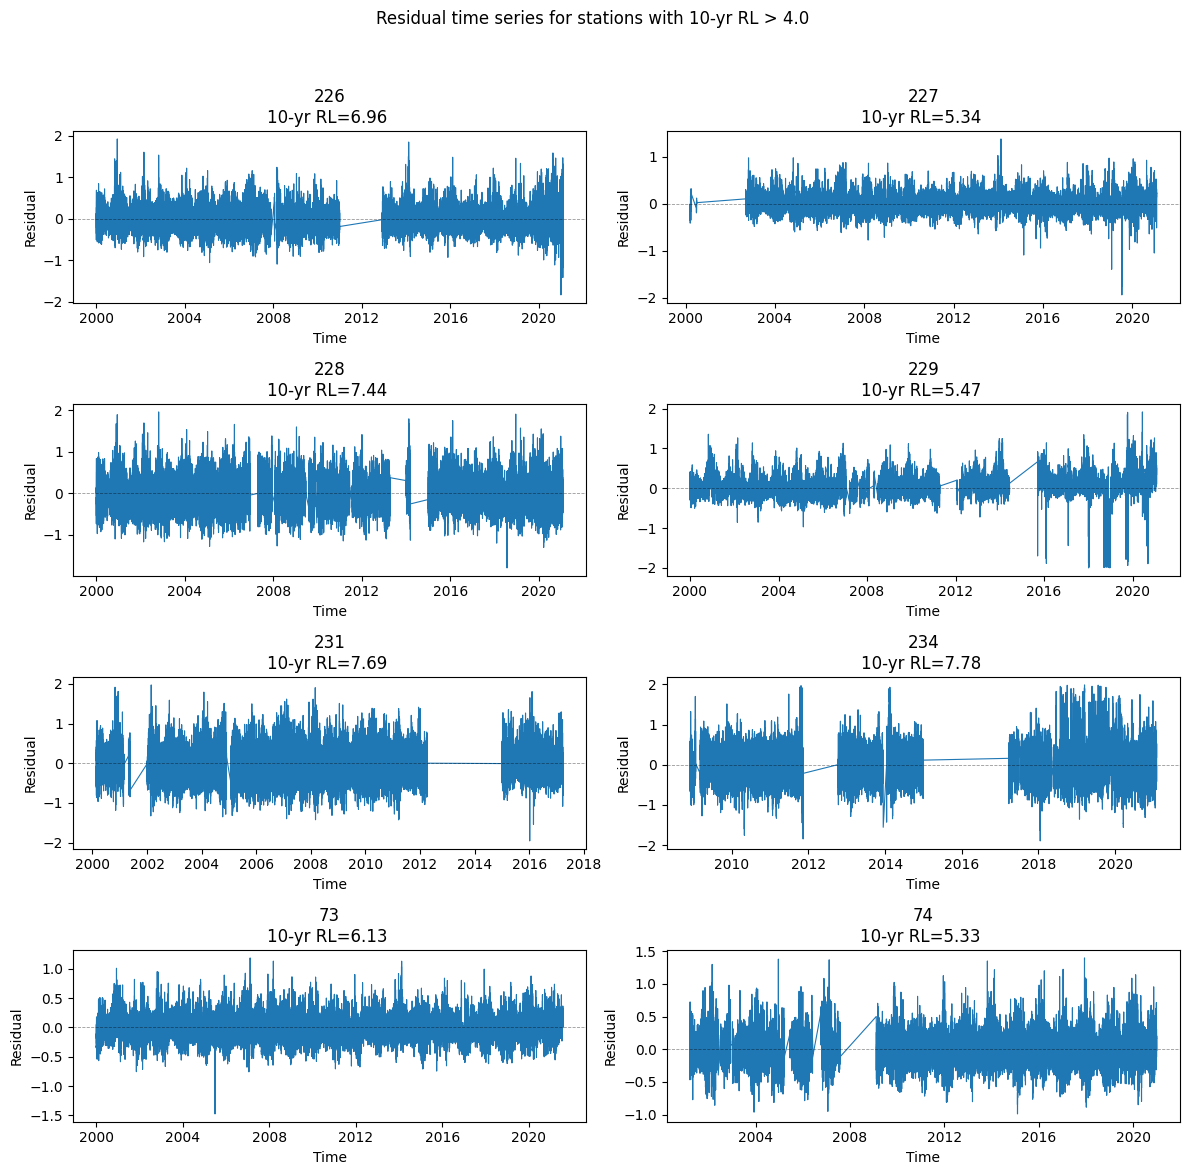

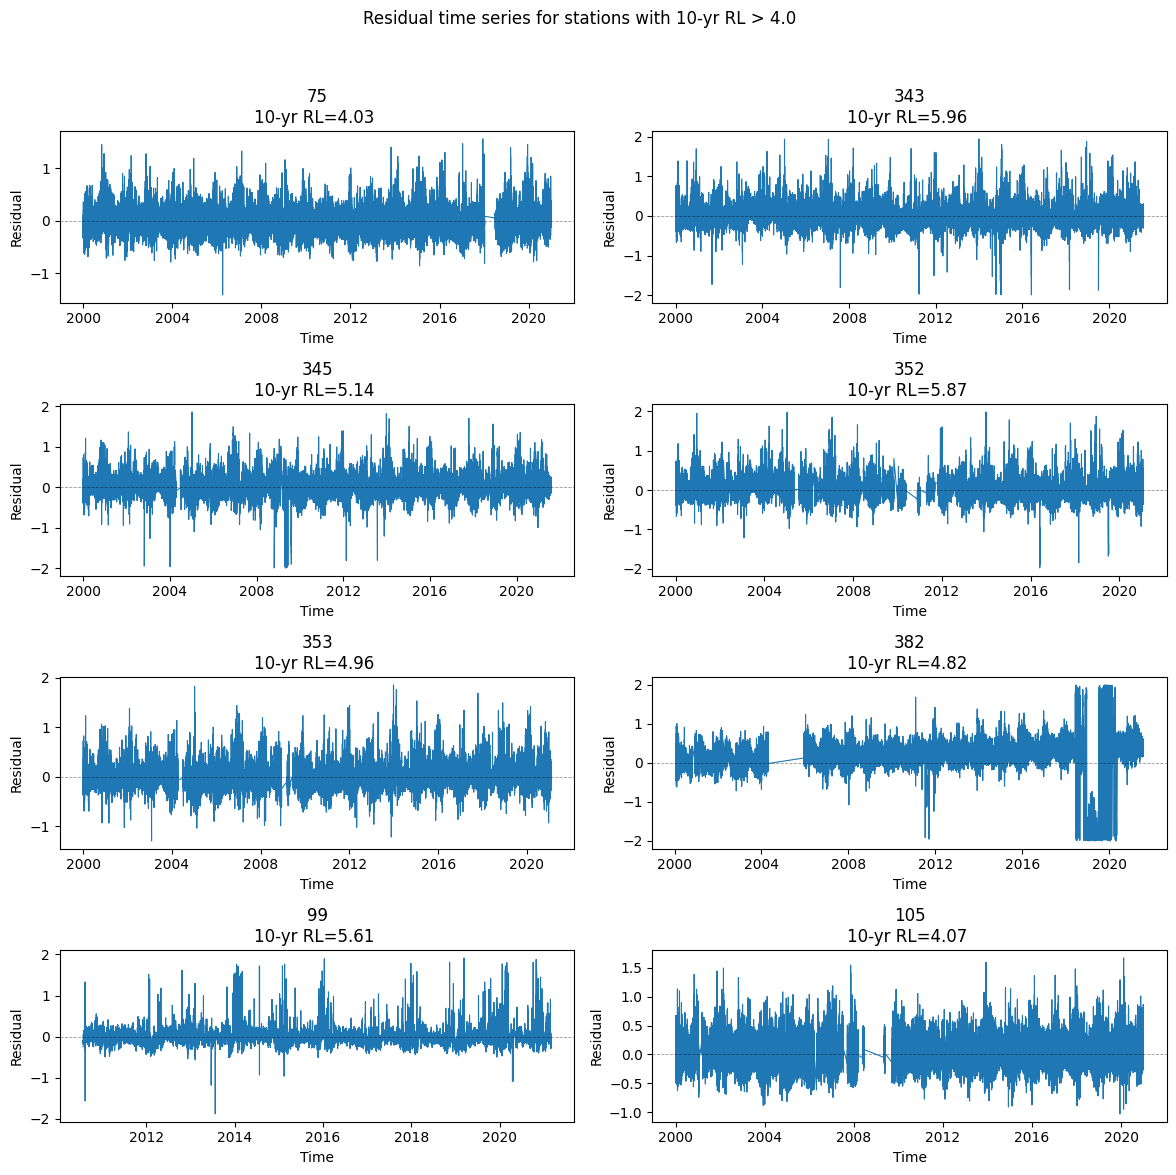

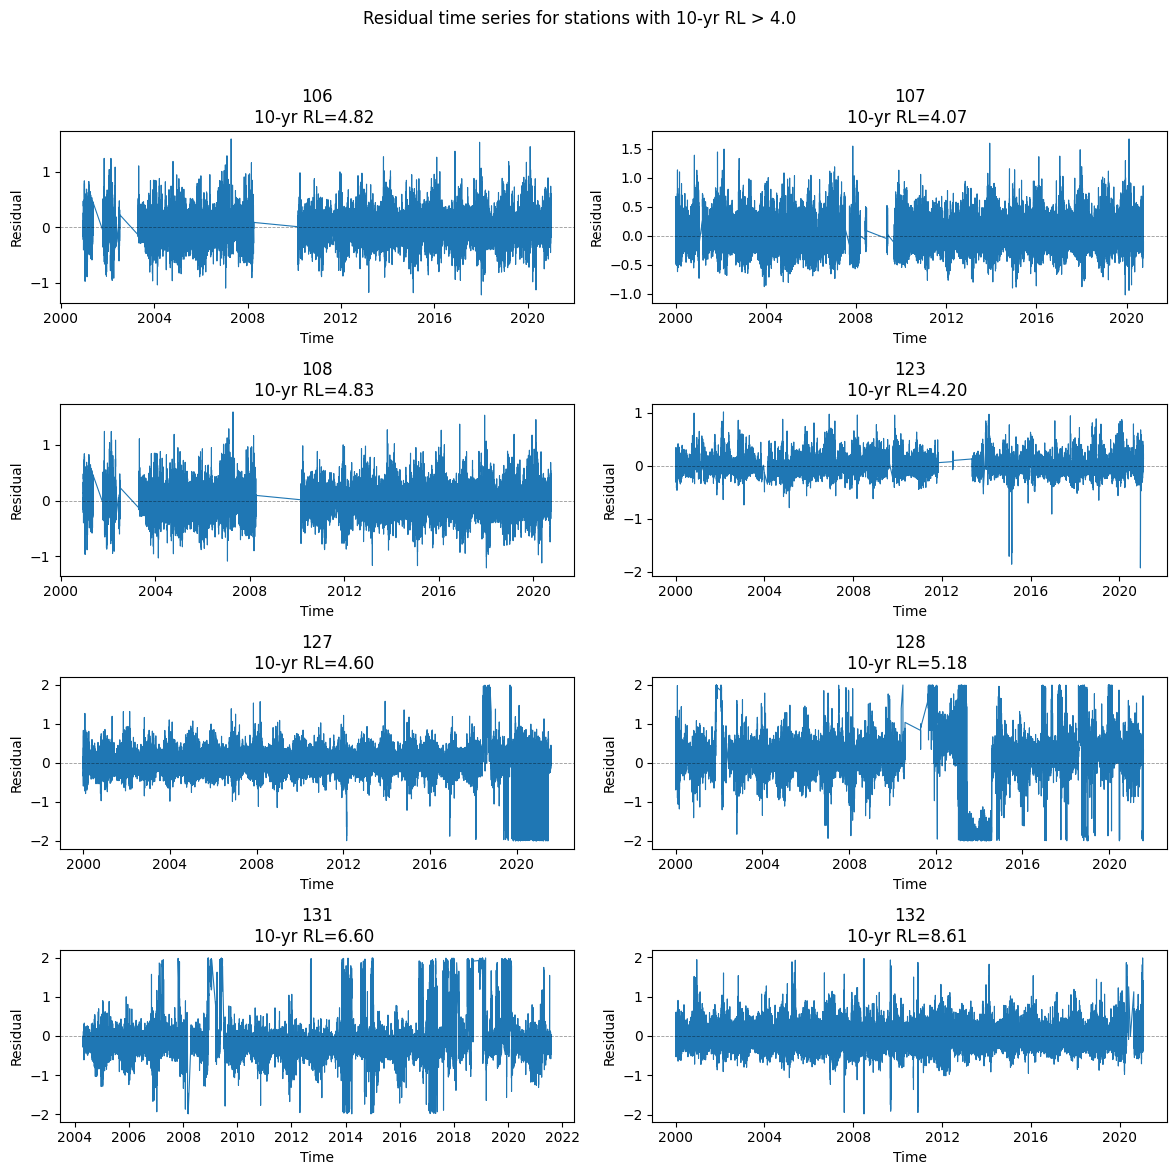

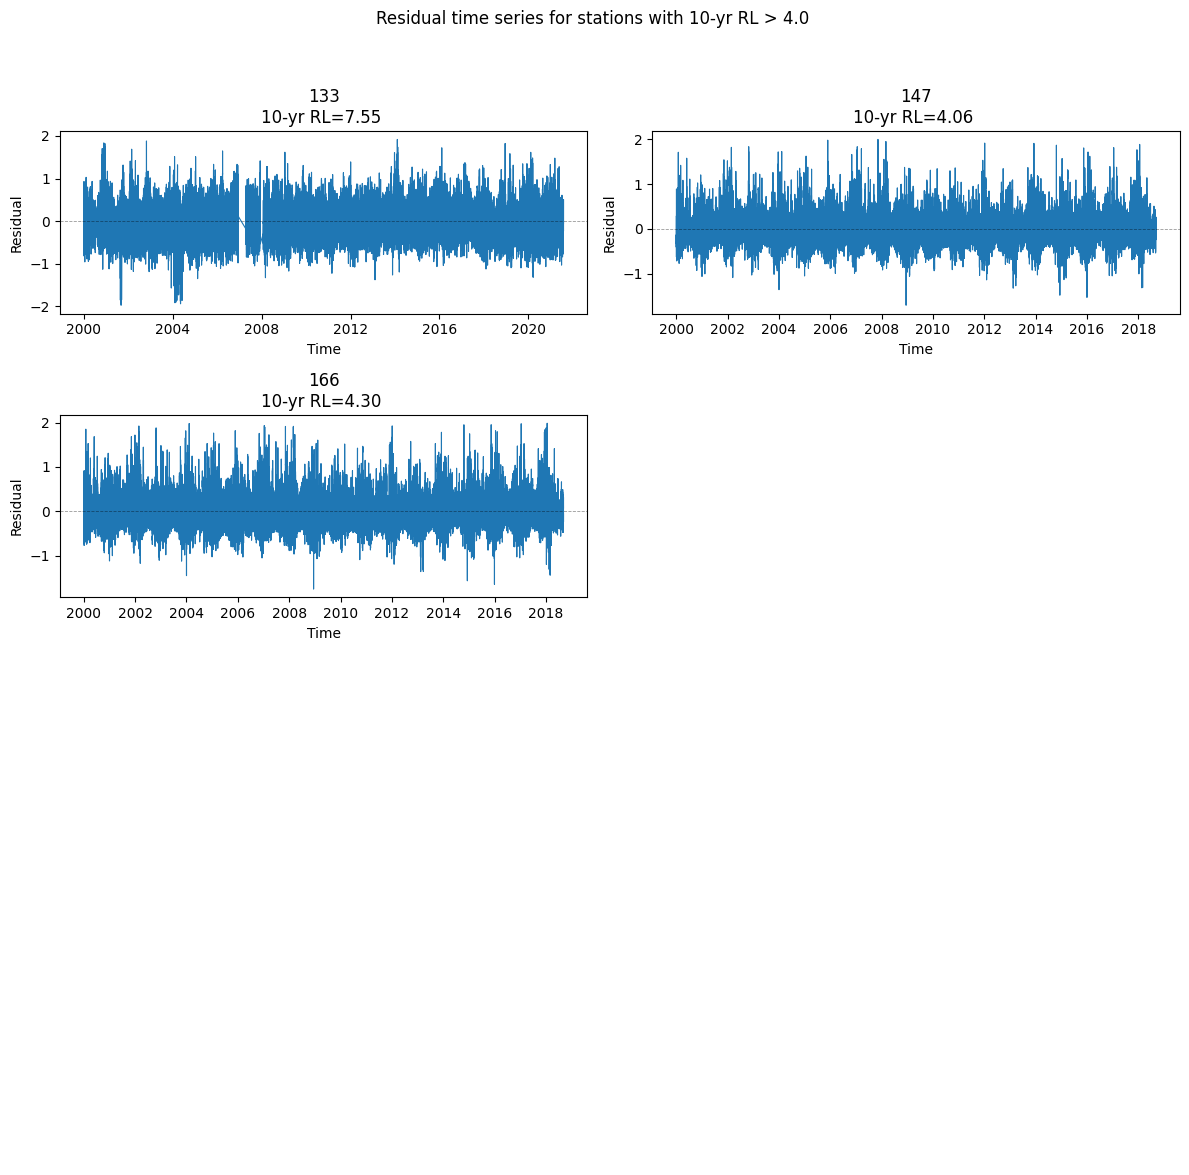

In [9]:
import math
import xarray as xr

# --- pick stations with 10-yr RL > 5 m (and at least 10 years) ---
thr = 4.0
mask = (tenyr_rl > thr) & (n_years >= 10)
hot = tenyr_rl.where(mask, drop=True)          # (station,)
hot_idx = hot.get_index("station")             # indexer to select stations
print(f"{hot.sizes.get('station', 0)} stations exceed {thr} m 10-yr RL")

# Try to get readable station labels
if "station_name" in ds:
    station_labels = ds["station_name"].sel(station=hot_idx).astype(str).values
elif "station_id" in ds:
    station_labels = ds["station_id"].sel(station=hot_idx).astype(str).values
else:
    # fall back to coord value
    station_labels = [str(s) for s in hot["station"].values]

# --- plot residual time series for each selected station ---
# choose layout
n = hot.sizes["station"]
ncols = 2
nrows = min(4, math.ceil(n / ncols))  # up to 8 panels per figure
per_fig = ncols * nrows

# OPTIONAL: save all panels to a single PDF
from matplotlib.backends.backend_pdf import PdfPages
save_pdf = True
pdf_path = "residual_timeseries_hotstations.pdf"
pdf = PdfPages(pdf_path) if save_pdf else None

for i0 in range(0, n, per_fig):
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.0*nrows), sharex=False, sharey=False)
    axes = np.atleast_1d(axes).ravel()

    for ax, j in zip(axes, range(i0, min(i0+per_fig, n))):
        st_sel = hot.isel(station=j)
        st_id = st_sel["station"].item()
        ts = ds["residual"].sel(station=st_id).dropna("valid_time")
        # sort by time just in case
        ts = ts.sortby("valid_time")

        ax.plot(ts["valid_time"].values, ts.values, lw=0.8)
        ax.axhline(0, lw=0.6, ls="--", color="k", alpha=0.4)
        ax.set_title(f"{station_labels[j]}\n10-yr RL={float(st_sel.values):.2f} {units or ''}")
        ax.set_xlabel("Time")
        ax.set_ylabel(f"Residual ({units})" if units else "Residual")

    # Hide unused axes on the last page
    for ax in axes[(min(i0+per_fig, n) - i0):]:
        ax.axis("off")

    fig.suptitle(f"Residual time series for stations with 10-yr RL > {thr} {units or ''}", y=0.995)
    fig.tight_layout(rect=[0, 0.02, 1, 0.97])

In [8]:
# Ensure time is sorted (important for derivatives)
ds = ds.sortby("valid_time")

# --- Core helpers (finite differences over hours) ---
def diff_hours(da, hours: int):
    """Finite-difference derivative over 'hours' (value change per hour)."""
    return (da - da.shift(valid_time=hours)) / hours

# --- Wind features ---
u = ds["u10"]
v = ds["v10"]
wind_speed = np.hypot(u, v).rename("wind_speed")

d_wind_1h = diff_hours(wind_speed, 1).rename("d_wind_1h")   # Δwind / 1h
d_wind_6h = diff_hours(wind_speed, 6).rename("d_wind_6h")   # Δwind / 6h

# --- Pressure derivatives (dsp/dt) ---
sp = ds["sp"]
d_sp_1h = diff_hours(sp, 1).rename("d_sp_1h")
d_sp_6h = diff_hours(sp, 6).rename("d_sp_6h")

# --- Tide shifted features ---
tide_lag1h = ds["tide"].shift(valid_time=1).rename("tide_lag1h")
tide_lag6h = ds["tide"].shift(valid_time=6).rename("tide_lag6h")
tide_lag0h = ds["tide"].shift(valid_time=0).rename("tide_lag0h")

# Make sure sorted
ds = ds.sortby("valid_time")

# Pull just tide to a tidy frame
df = ds[["tide"]].to_dataframe().reset_index()
df = df.sort_values(["station", "valid_time"])

# Compute tidal range per station (across all valid_time)
tide_range = (ds["tide"].max(dim="valid_time") - ds["tide"].min(dim="valid_time"))
tide_range = tide_range.rename("tide_range")

# --- Air density (rho_air) ---
# Use sp (Pa) and t2m (K) if available; else fallback to 1.225 kg/m^3
R_d = 287.05  # J kg^-1 K^-1
if "sp" in ds and "t2m" in ds:
    rho_air = (ds["sp"] / (R_d * ds["t2m"])).astype("float32").rename("rho_air")
else:
    rho_air = xr.zeros_like(wind_speed) + 1.225
    rho_air = rho_air.astype("float32").rename("rho_air")

# --- Drag coefficient C_D (Large & Pond style) ---
U = wind_speed
Cd = xr.where(
    U < 11.0,
    1.14e-3,
    xr.where(U <= 25.0, (0.49 + 0.065 * U) * 1e-3, 2.0e-3)
).astype("float32").rename("Cd")

# --- Wind stress components (N/m^2 = Pa) ---
tau_x = (rho_air * Cd * U * u).astype("float32").rename("tau_x")
tau_y = (rho_air * Cd * U * v).astype("float32").rename("tau_y")
tau_mag = (rho_air * Cd * U**2).astype("float32").rename("tau_mag")

# Optional: tendencies (change over 1h/6h), consistent with your diff_hours helper
tau_d1h = diff_hours(tau_mag, 1).astype("float32").rename("d_tau_1h")
tau_d6h = diff_hours(tau_mag, 6).astype("float32").rename("d_tau_6h")

# --- Assemble into one dataset ---
feat_ds = xr.Dataset(
    {
        "wind_speed": wind_speed,
        "d_wind_1h": d_wind_1h,
        "d_wind_6h": d_wind_6h,
        "d_sp_1h": d_sp_1h,
        "d_sp_6h": d_sp_6h,
        "tide_range_12h": tide_range,
        "tide_lag0h": tide_lag0h,
        "tide_lag1h": tide_lag1h,
        "tide_lag6h": tide_lag6h,
        # "d_msl_1h": d_msl_1h,  # uncomment if you computed these
        # "d_msl_6h": d_msl_6h,
        "tau_x": tau_x,
        "tau_y": tau_y,
        "tau_mag": tau_mag,
        "tau_d1h": tau_d1h,
        "tau_d6h": tau_d6h,
    }
)

# Keep original coordinates/attrs
feat_ds = feat_ds.assign_coords(
    station=ds["station"],
    valid_time=ds["valid_time"]
)
for v in feat_ds.data_vars:
    feat_ds[v].attrs.update(ds[v.split("_")[0]].attrs if v.split("_")[0] in ds.data_vars else {})

# Merge features back with original dataset (optional)
ds_engineered = xr.merge([ds, feat_ds])

In [9]:
# exclude target + sea_level + tide from predictors
predictors = [v for v in ds_engineered.data_vars if v not in ["residual", "sea_level", "tide", "longitude", "latitude", "station_longitude", "station_latitude", "station", "valid_time"]]
target = "residual"
df = ds_engineered[predictors + [target]].to_dataframe().reset_index()
df = df.dropna(subset=[target])

# No!

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
RANDOM_SEED=42

def stats(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2   = r2_score(y_true, y_pred)
    denom = np.where(np.abs(y_true) < 1e-8, np.nan, np.abs(y_true))
    mape = np.nanmean(np.abs((y_true - y_pred) / denom)) * 100.0
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE_%": mape}

station_scores = []
X_cols = predictors 

# loop over each station separately
for st in df["station"].unique():
    df_st = df[df["station"] == st].sort_values("valid_time")

    # simple random split: 80% train, 20% test (by time order)
    n = len(df_st)
    n_train = int(0.8 * n)
    train_df, test_df = df_st.iloc[:n_train], df_st.iloc[n_train:]

    X_train, y_train = train_df[X_cols], train_df[target]
    X_test,  y_test  = test_df[X_cols],  test_df[target]

    model = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        tree_method="hist",
        objective="reg:squarederror",
        eval_metric="mae",
    )

    model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

    y_pred = model.predict(X_test)
    station_scores.append({"station": st, **stats(y_test, y_pred)})

# Summarise
scores_df = pd.DataFrame(station_scores).set_index("station")
print("\n=== Per-station scores (trained & tested on same station) ===")
print(scores_df.to_string(float_format=lambda x: f"{x:.4f}"))

print("\nMean across stations:")
print(scores_df.mean().to_string(float_format=lambda x: f"{x:.4f}"))

KeyboardInterrupt: 

In [9]:
scores_df = scores_df.reset_index()

In [10]:
import pandas as pd
import numpy as np

# --- Extract per-station coordinates from ds ---
station_vals = np.ravel(ds["station"].values)
lat_vals     = np.ravel(ds["station_latitude"].values)
lon_vals     = np.ravel(ds["station_longitude"].values)

coords_df = pd.DataFrame({
    "station": station_vals,
    "lat": lat_vals,
    "lon": lon_vals
}).drop_duplicates("station")

# --- Merge with your scores_df ---
scores_with_coords = (
    scores_df.reset_index()   # bring 'station' back as column
             .merge(coords_df, on="station", how="left")
             .set_index("station")
)

print(scores_with_coords.head())


         index       MAE      RMSE        R2      MAPE_%        lat       lon
station                                                                      
1            0  0.049762  0.063779  0.781796  363.886257  60.155000 -1.140000
2            1  0.055453  0.070592  0.775021  306.106583  61.933000  5.117000
3            2  0.114677  0.231471  0.179630  311.365458  60.154028 -1.140306
4            3  0.106804  0.129817  0.356080  442.011599  60.398046  5.320487
5            4  0.118112  0.145053  0.406240  755.033990  61.933776  5.113310


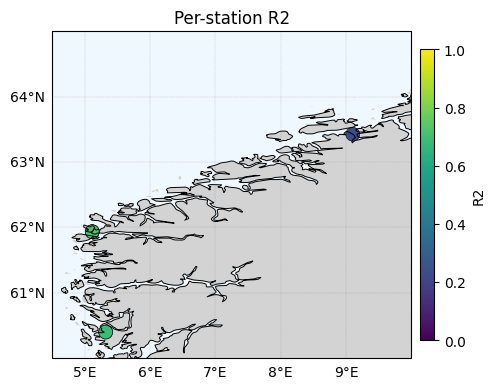

In [11]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import Normalize

# Choose metric to color by
color_metric = "R2"

# Projection
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(5, 4))
ax = plt.axes(projection=proj)

# Extent with a little padding
xmin, xmax = float(scores_with_coords["lon"].min()), float(scores_with_coords["lon"].max())
ymin, ymax = float(scores_with_coords["lat"].min()), float(scores_with_coords["lat"].max())
pad_x = max(0.5, 0.05 * (xmax - xmin))
pad_y = max(0.5, 0.05 * (ymax - ymin))
ax.set_extent([xmin - pad_x, xmax + pad_x, ymin - pad_y, ymax + pad_y], crs=proj)
ax.set_extent([4.5, 10, 60, 65], crs=proj)

# Base layers
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue")
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5, linestyle="--")
gl.right_labels = False
gl.top_labels = False

# Scatter: color = metric, size fixed (or scale by #obs if you want)
norm = Normalize(vmin=min(0, scores_with_coords[color_metric].min()), vmax=1.0)
sc = ax.scatter(
    scores_with_coords["lon"], scores_with_coords["lat"],
    c=scores_with_coords[color_metric],
    s=100, cmap="viridis", norm=norm,
    edgecolor="black", linewidth=0.4, alpha=1,
    transform=proj
)

# Colorbar
cb = plt.colorbar(sc, ax=ax, fraction=0.036, pad=0.02)
cb.set_label(color_metric)

ax.set_title(f"Per-station {color_metric}")
plt.tight_layout()
plt.show()


# Train on full

In [10]:
RANDOM_SEED=42

In [11]:
def stats(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2   = r2_score(y_true, y_pred)
    denom = np.where(np.abs(y_true) < 1e-8, np.nan, np.abs(y_true))
    mape = np.nanmean(np.abs((y_true - y_pred) / denom)) * 100.0
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE_%": mape}

rng = np.random.default_rng(RANDOM_SEED)
stations = np.array(sorted(df["station"].unique()))
perm = rng.permutation(stations)

n = len(perm)
n_train = int(round(0.70 * n))
n_val   = int(round(0.10 * n))
n_test  = n - n_train - n_val

train_stn = set(perm[:n_train])
val_stn   = set(perm[n_train:n_train + n_val])
test_stn  = set(perm[n_train + n_val:])

m_train = df["station"].isin(train_stn)
m_val   = df["station"].isin(val_stn)
m_test  = df["station"].isin(test_stn)

X_cols = predictors  # all other variables as predictors

X_train, y_train = df.loc[m_train, X_cols], df.loc[m_train, target]
X_val,   y_val   = df.loc[m_val,   X_cols], df.loc[m_val,   target]
X_test,  y_test  = df.loc[m_test,  X_cols], df.loc[m_test,  target]

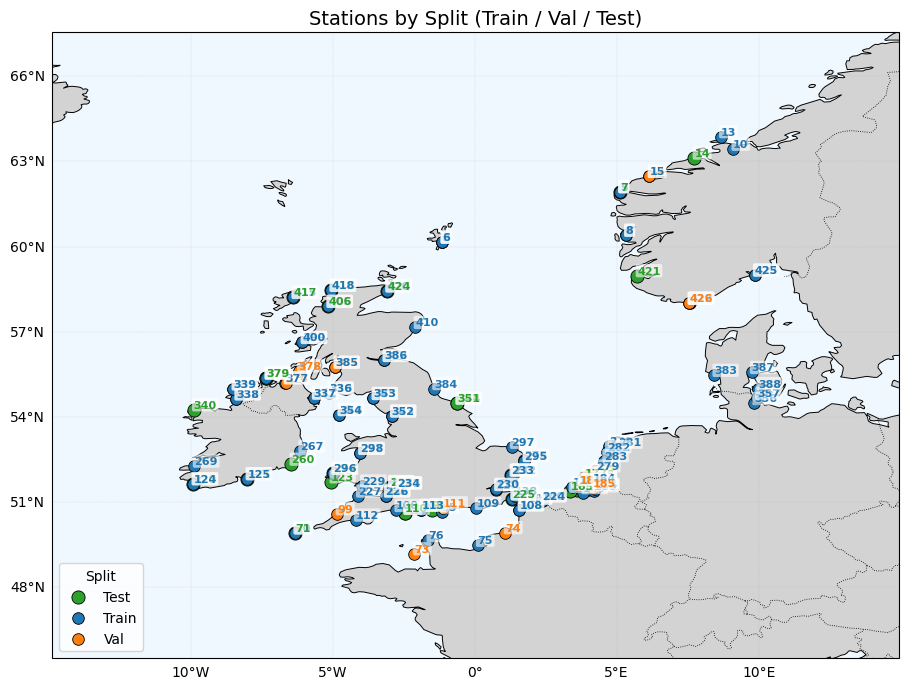

Saved: station_split_map.png


In [12]:
# pip install cartopy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1) Unique stations with coordinates
st_meta = (
    df[["station", "station_latitude", "station_longitude"]]
    .dropna(subset=["station_latitude", "station_longitude"])
    .drop_duplicates(subset=["station"])
    .sort_values("station")
    .reset_index(drop=True)
)

# 2) Add split label
def split_label(s):
    if s in train_stn: return "train"
    if s in val_stn:   return "val"
    if s in test_stn:  return "test"
    return "unknown"

st_meta["split"] = st_meta["station"].apply(split_label)

# 3) Map setup
lon_min, lon_max = st_meta["station_longitude"].min(), st_meta["station_longitude"].max()
lat_min, lat_max = st_meta["station_latitude"].min(),  st_meta["station_latitude"].max()

# pad the extent a bit
d_lon = (lon_max - lon_min) or 1.0
d_lat = (lat_max - lat_min) or 1.0
pad = 0.25
extent = [lon_min - pad*d_lon, lon_max + pad*d_lon,
          lat_min - pad*d_lat, lat_max + pad*d_lat]

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection=proj)
ax.set_extent(extent, crs=proj)

# basemap features
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.6)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, linestyle="--")
gl.right_labels = False
gl.top_labels = False

# 4) Plot by split
colors = {"train": "tab:blue", "val": "tab:orange", "test": "tab:green", "unknown": "gray"}
sizes  = {"train": 70, "val": 70, "test": 90, "unknown": 60}  # make test a bit bigger

for split, df_split in st_meta.groupby("split"):
    ax.scatter(
        df_split["station_longitude"], df_split["station_latitude"],
        s=sizes.get(split, 70),
        color=colors.get(split, "gray"),
        edgecolor="k",
        linewidth=0.6,
        transform=proj,
        zorder=5,
        label=split.capitalize()
    )

# 5) Optional: label station IDs
label_points = True
if label_points:
    for _, r in st_meta.iterrows():
        ax.text(
            r["station_longitude"], r["station_latitude"],
            f'{int(r["station"])}',
            transform=proj,
            fontsize=8, weight="bold",
            ha="left", va="bottom",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.6),
            zorder=6,
            color=colors.get(r["split"], "black")
        )

# legend & title
handles, labels = ax.get_legend_handles_labels()
# deduplicate legend entries
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), loc="lower left", title="Split")
plt.title("Stations by Split (Train / Val / Test)", fontsize=14)
plt.tight_layout()
plt.savefig("station_split_map.png", dpi=150)
plt.show()

print("Saved: station_split_map.png")


In [15]:
# ---------------------------
# 4) Generalized Linear Model
# ---------------------------
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# We’ll keep the sample weighting if you still want to emphasize extremes
thr = np.quantile(y_train, 0.95)
w = np.ones_like(y_train, float)
w[y_train >= thr] = 3.0

# Pipeline: impute missing values -> scale -> Ridge regression
glm_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0, random_state=RANDOM_SEED))
])

glm_model.fit(X_train, y_train, ridge__sample_weight=w)

# ---------------------------
# 5) Evaluate
# ---------------------------
def evaluate(name, X, y, m):
    pred = m.predict(X)
    r2 = r2_score(y, pred)
    mae = mean_absolute_error(y, pred)
    print(f"{name:>5} | R2: {r2:.4f} | MAE: {mae:.4f}")
    return pred

print("Performance:")
_ = evaluate("Train", X_train, y_train, glm_model)
_ = evaluate(" Val ", X_val,   y_val,   glm_model)
test_pred = evaluate("Test ", X_test,  y_test,  glm_model)

# ---------------------------
# 6) Save model + test predictions
# ---------------------------
# joblib.dump({"model": glm_model, "features": X_cols}, "glm_residual_model.joblib")
out = df.loc[m_test, ["station", "valid_time", target]].copy()
out["residual_pred"] = test_pred
out.sort_values(["station", "valid_time"]).to_parquet("test_predictions_glm.parquet", index=False)

print("Saved: glm_residual_model.joblib")
print("Saved: test_predictions_glm.parquet")

Performance:
Train | R2: 0.2038 | MAE: 0.1360
 Val  | R2: 0.0643 | MAE: 0.1339
Test  | R2: 0.1544 | MAE: 0.1260
Saved: glm_residual_model.joblib
Saved: test_predictions_glm.parquet


In [ ]:
# ============================================================
# Low-memory STATION-WISE LSTM via tf.data (streaming windows)
# ============================================================
import os, gc
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# ---- (A) Stability & memory hygiene
os.environ.setdefault("TF_FORCE_GPU_ALLOW_GROWTH", "true")   # avoid full GPU prealloc
# Uncomment if your GPU/driver is flaky:
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

WINDOW      = 24
BATCH_SIZE  = 128   # smaller batch to reduce peak memory
MAX_EPOCHS  = 200
PATIENCE_ES = 10
PATIENCE_RLP= 5
TAIL_WEIGHT = 3.0

# ---- (B) Helpers
def _sorted_split(df, mask):
    d = df.loc[mask].sort_values(["station", "valid_time"]).copy()
    d.reset_index(drop=False, inplace=True)             # keep original index
    d.rename(columns={"index": "_orig_idx"}, inplace=True)
    return d

df_tr = _sorted_split(df, m_train)
df_va = _sorted_split(df, m_val)
df_te = _sorted_split(df, m_test)

# Train-only impute + scale (float32 to halve memory)
imp   = SimpleImputer(strategy="median")
scaler= StandardScaler()

X_tr = imp.fit_transform(df_tr[X_cols].to_numpy()).astype("float32")
X_va = imp.transform(    df_va[X_cols].to_numpy()).astype("float32")
X_te = imp.transform(    df_te[X_cols].to_numpy()).astype("float32")

y_tr = df_tr[target].to_numpy().astype("float32")
y_va = df_va[target].to_numpy().astype("float32")
y_te = df_te[target].to_numpy().astype("float32")

X_tr = scaler.fit_transform(X_tr).astype("float32")
X_va = scaler.transform(    X_va).astype("float32")
X_te = scaler.transform(    X_te).astype("float32")

# ---- (C) Scan once to get TRAIN target distribution and index maps (no big X tensors)
def scan_targets_and_indices(df_split, y_flat, window):
    ys, idxs = [], []
    start = 0
    for _, g in df_split.groupby("station", sort=False):
        n = len(g)
        idxg = g["_orig_idx"].to_numpy()
        yg   = y_flat[start:start+n]
        if n > window:
            for i in range(window, n):
                ys.append(yg[i])
                idxs.append(idxg[i])   # this sequence predicts row i
        start += n
    return np.array(ys, dtype="float32"), np.array(idxs, dtype=np.int64)

y_tr_seq, idx_tr = scan_targets_and_indices(df_tr, y_tr, WINDOW)
y_va_seq, idx_va = scan_targets_and_indices(df_va, y_va, WINDOW)
y_te_seq, idx_te = scan_targets_and_indices(df_te, y_te, WINDOW)  # used only for saving in right order

# Tail-aware sample weights (train only)
thr = np.quantile(y_tr_seq, 0.95)
w_tr = np.ones_like(y_tr_seq, dtype="float32")
w_tr[y_tr_seq >= thr] = TAIL_WEIGHT

# ---- (D) Window generators (yield one sequence at a time, per station)
def gen_sequences(df_split, X_flat, y_flat, window, with_weights=False, thr_val=None, tail_w=3.0):
    start = 0
    for _, g in df_split.groupby("station", sort=False):
        n   = len(g)
        Xg  = X_flat[start:start+n]
        yg  = y_flat[start:start+n]
        if n > window:
            for i in range(window, n):
                seqX = Xg[i-window:i, :]
                target = yg[i]
                if with_weights:
                    w = tail_w if (thr_val is not None and target >= thr_val) else 1.0
                    yield (seqX.astype("float32"), np.float32(target), np.float32(w))
                else:
                    yield (seqX.astype("float32"), np.float32(target))
        start += n

# ---- (E) Build tf.data datasets from generators
T = WINDOW
F = X_tr.shape[1]

def make_ds_train():
    output_sig = (
        tf.TensorSpec(shape=(T, F), dtype=tf.float32),
        tf.TensorSpec(shape=(),    dtype=tf.float32),
        tf.TensorSpec(shape=(),    dtype=tf.float32),
    )
    ds = tf.data.Dataset.from_generator(
        lambda: gen_sequences(df_tr, X_tr, y_tr, WINDOW, with_weights=True, thr_val=thr, tail_w=TAIL_WEIGHT),
        output_signature=output_sig
    )
    ds = ds.shuffle(4096, seed=RANDOM_SEED, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

def make_ds_eval(df_split, X_flat, y_flat):
    output_sig = (
        tf.TensorSpec(shape=(T, F), dtype=tf.float32),
        tf.TensorSpec(shape=(),    dtype=tf.float32),
    )
    ds = tf.data.Dataset.from_generator(
        lambda: gen_sequences(df_split, X_flat, y_flat, WINDOW, with_weights=False),
        output_signature=output_sig
    )
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds_train()
val_ds   = make_ds_eval(df_va, X_va, y_va)
test_ds  = make_ds_eval(df_te, X_te, y_te)   # for predictions

# ---- (F) Define & train a compact LSTM
# Smaller model to reduce memory; bump units if you have headroom.
model = Sequential([
    LSTM(32, input_shape=(T, F)),   # 32 units instead of 64
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mae", metrics=["mae"])

callbacks = [
    EarlyStopping(monitor="val_loss", patience=PATIENCE_ES, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=PATIENCE_RLP, min_lr=1e-5),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS,
    class_weight=None,              # we pass sample weights in the dataset itself
    callbacks=callbacks,
    verbose=1
)

# ---- (G) Evaluate with your stats()
def collect_preds(ds):
    y_true, y_pred = [], []
    for batch in ds:
        if isinstance(batch, (list, tuple)) and len(batch) == 2:
            xb, yb = batch
        else:
            xb = batch
            yb = None
        pb = model.predict(xb, verbose=0).squeeze()
        if yb is not None:
            y_true.append(yb.numpy())
        y_pred.append(pb)
    y_true = np.concatenate(y_true) if len(y_true) else None
    y_pred = np.concatenate(y_pred)
    return y_true, y_pred

y_tr_true, y_tr_pred = collect_preds(train_ds.unbatch().batch(BATCH_SIZE))
y_va_true, y_va_pred = collect_preds(val_ds)
y_te_true, y_te_pred = collect_preds(test_ds)

print("Performance:")
print("Train |", " | ".join(f"{k}: {v:.4f}" for k, v in stats(y_tr_true, y_tr_pred).items()))
print(" Val  |", " | ".join(f"{k}: {v:.4f}" for k, v in stats(y_va_true, y_va_pred).items()))
print(" Test |", " | ".join(f"{k}: {v:.4f}" for k, v in stats(y_te_true, y_te_pred).items()))

# ---- (H) Save model + aligned test predictions (order follows idx_te we scanned earlier)
model.save("lstm_residual_model_stationwise_stream.h5")

out = df.loc[idx_te, ["station", "valid_time", target]].copy()
out["residual_pred"] = y_te_pred
out = out.sort_values(["station", "valid_time"])
out.to_parquet("test_predictions_lstm_stationwise_stream.parquet", index=False)

print("Saved: lstm_residual_model_stationwise_stream.h5")
print("Saved: test_predictions_lstm_stationwise_stream.parquet")

# Clean up (optional)
gc.collect()

Epoch 1/200


/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  63761/Unknown 777s 12ms/step - loss: 0.1001 - mae: 0.0854

In [14]:
# ---------------------------
# 4) XGBoost model
# ---------------------------
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# ---------------------------
# 4) XGBoost model (emphasize extremes via sample_weight)
# ---------------------------
thr = np.quantile(y_train, 0.95)
w = np.ones_like(y_train, float)
w[y_train >= thr] = 3.0  # try 2–5 first, not 10–50

model = XGBRegressor(
    n_estimators=800,           # a bit more estimators with low LR
    learning_rate=0.015,
    max_depth=6,               # shallower to reduce overfit in tail
    min_child_weight=10,       # stronger regularization
    subsample=0.8,
    colsample_bytree=0.6,
    reg_lambda=10.0,
    gamma=1.0,                 # discourage tiny splits
    tree_method="hist",
    objective="reg:squarederror",
    eval_metric="mae",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

model.fit(X_train, y_train, sample_weight=w, eval_set=[(X_val, y_val)], verbose=False)

# ---------------------------
# 5) Evaluate
# ---------------------------
def evaluate(name, X, y, m):
    pred = m.predict(X)
    r2 = r2_score(y, pred)
    mae = mean_absolute_error(y, pred)
    print(f"{name:>5} | R2: {r2:.4f} | MAE: {mae:.4f}")
    return pred

print("Performance:")
_ = evaluate("Train", X_train, y_train, model)
_ = evaluate(" Val ", X_val,   y_val,   model)
test_pred = evaluate("Test ", X_test,  y_test,  model)

# ---------------------------
# 6) Save model + test predictions
# ---------------------------
#joblib.dump({"model": model, "features": X_cols}, "xgb_residual_model.joblib")
out = df.loc[m_test, ["station", "valid_time", target]].copy()
out["residual_pred"] = test_pred
out.sort_values(["station", "valid_time"]).to_parquet("test_predictions.parquet", index=False)

print("Saved: xgb_residual_model.joblib")
print("Saved: test_predictions.parquet")

Performance:
Train | R2: 0.3750 | MAE: 0.1168
 Val  | R2: 0.3968 | MAE: 0.1138
Test  | R2: 0.2622 | MAE: 0.1153
Saved: xgb_residual_model.joblib
Saved: test_predictions.parquet


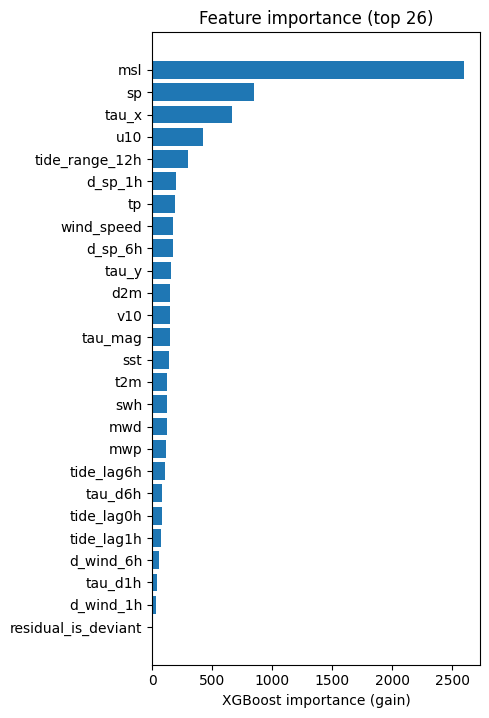

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Choose which importance definition you want: 'gain', 'weight', 'cover', 'total_gain', 'total_cover'
importance_type = 'gain'

# Grab importance from booster with your feature names
booster = model.get_booster()
# X_cols should be a list-like of your training column names (order must match X_train)
booster.feature_names = list(map(str, X_cols))

score_dict = booster.get_score(importance_type=importance_type)
# Ensure all features appear (fill missing with 0)
imp = np.array([score_dict.get(str(f), 0.0) for f in X_cols], dtype=float)

order = np.argsort(imp)[::-1]
top_k = 30  # show top-N
order = order[:top_k]

plt.figure(figsize=(5, max(2, 0.28*len(order))))
plt.barh(np.array(X_cols)[order][::-1], imp[order][::-1])
plt.xlabel(f"XGBoost importance ({importance_type})")
plt.title("Feature importance (top {})".format(len(order)))
plt.tight_layout()
plt.show()


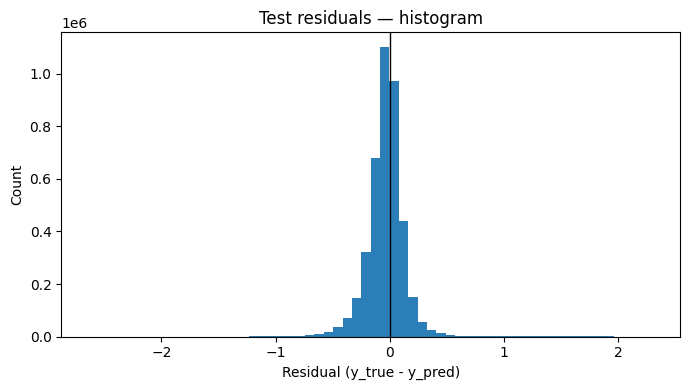

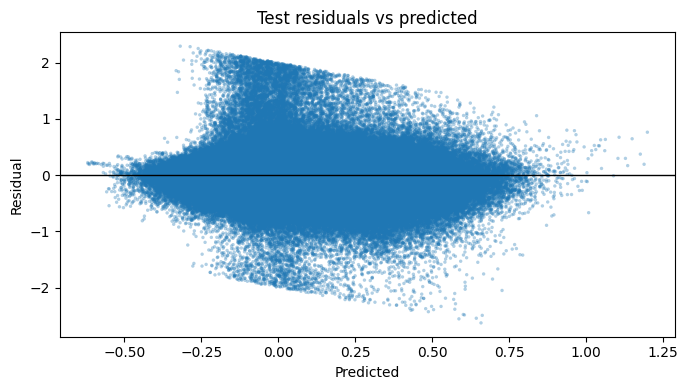

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# If starting fresh, load what you saved:
# out = pd.read_parquet("test_predictions.parquet")

# Make sure the columns are named consistently
preds = out.rename(columns={"residual_pred": "y_pred", target: "y_true"}).copy()
preds["valid_time"] = pd.to_datetime(preds["valid_time"])
preds["residual"] = preds["y_true"] - preds["y_pred"]

# --- A) Residual histogram ---
plt.figure(figsize=(7,4))
plt.hist(preds["residual"].dropna(), bins=60, alpha=0.95)
plt.axvline(0, color="k", lw=1)
plt.xlabel("Residual (y_true - y_pred)")
plt.ylabel("Count")
plt.title("Test residuals — histogram")
plt.tight_layout()
plt.show()

# --- B) Residuals vs Predicted (heteroscedasticity check) ---
plt.figure(figsize=(7,4))
plt.scatter(preds["y_pred"], preds["residual"], s=6, alpha=0.35, edgecolors="none")
plt.axhline(0, color="k", lw=1)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Test residuals vs predicted")
plt.tight_layout()
plt.show()


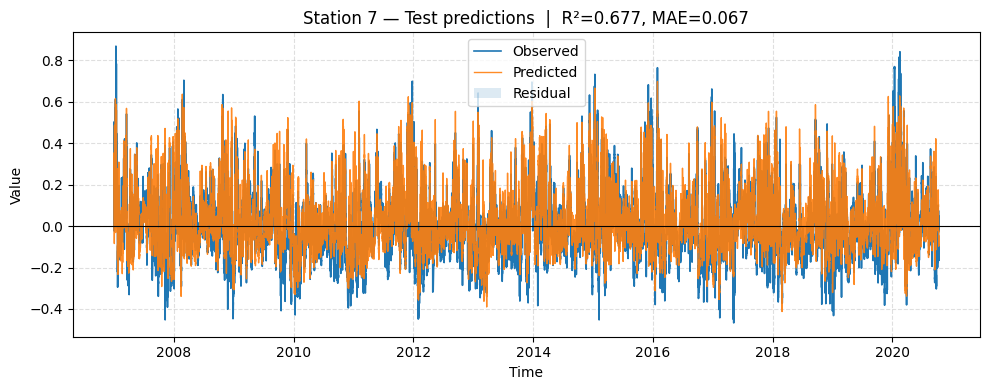

In [18]:
from sklearn.metrics import r2_score, mean_absolute_error

def plot_station_residuals(station_id):
    g = preds[preds["station"] == station_id].sort_values("valid_time")
    if g.empty:
        print(f"No test rows for station {station_id}")
        return
    r2  = r2_score(g["y_true"], g["y_pred"])
    mae = mean_absolute_error(g["y_true"], g["y_pred"])

    plt.figure(figsize=(10,4))
    plt.plot(g["valid_time"], g["y_true"], label="Observed", lw=1.2)
    plt.plot(g["valid_time"], g["y_pred"], label="Predicted", lw=1.0, alpha=0.9)
    plt.fill_between(g["valid_time"], g["y_pred"], g["y_true"], alpha=0.15, label="Residual")
    plt.axhline(0, color="k", lw=0.8)
    plt.title(f"Station {station_id} — Test predictions  |  R²={r2:.3f}, MAE={mae:.3f}")
    plt.xlabel("Time"); plt.ylabel("Value"); plt.grid(True, ls="--", alpha=0.4)
    plt.legend(); plt.tight_layout(); plt.show()

# Example:
plot_station_residuals(preds['station'].iloc[0])


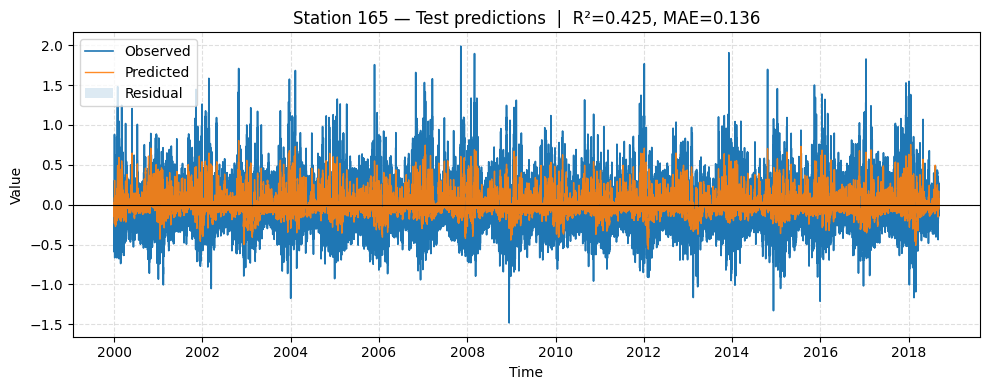

In [19]:
from sklearn.metrics import r2_score, mean_absolute_error

def plot_station_residuals(station_id):
    g = preds[preds["station"] == station_id].sort_values("valid_time")
    if g.empty:
        print(f"No test rows for station {station_id}")
        return
    r2  = r2_score(g["y_true"], g["y_pred"])
    mae = mean_absolute_error(g["y_true"], g["y_pred"])

    plt.figure(figsize=(10,4))
    plt.plot(g["valid_time"], g["y_true"], label="Observed", lw=1.2)
    plt.plot(g["valid_time"], g["y_pred"], label="Predicted", lw=1.0, alpha=0.9)
    plt.fill_between(g["valid_time"], g["y_pred"], g["y_true"], alpha=0.15, label="Residual")
    plt.axhline(0, color="k", lw=0.8)
    plt.title(f"Station {station_id} — Test predictions  |  R²={r2:.3f}, MAE={mae:.3f}")
    plt.xlabel("Time"); plt.ylabel("Value"); plt.grid(True, ls="--", alpha=0.4)
    plt.legend(); plt.tight_layout(); plt.show()

# Example:
plot_station_residuals(preds['station'].iloc[3736151])

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

def plot_station_residuals(station_id, year=None):
    g = preds[preds["station"] == station_id].sort_values("valid_time").copy()
    if g.empty:
        print(f"No test rows for station {station_id}")
        return
    
    if year is not None:
        g = g[g["valid_time"].dt.year == year]
        if g.empty:
            print(f"No test rows for station {station_id} in year {year}")
            return
    
    r2  = r2_score(g["y_true"], g["y_pred"])
    mae = mean_absolute_error(g["y_true"], g["y_pred"])

    plt.figure(figsize=(10,4))
    plt.plot(g["valid_time"], g["y_true"], label="Observed", lw=1.2)
    plt.plot(g["valid_time"], g["y_pred"], label="Predicted", lw=1.0, alpha=0.9)
    plt.fill_between(g["valid_time"], g["y_pred"], g["y_true"], alpha=0.15, label="Residual")
    plt.title(f"Station {station_id} — {year if year else 'Full period'}  |  R²={r2:.3f}, MAE={mae:.3f}")
    plt.xlabel("Time"); plt.ylabel("Value")
    plt.grid(True, ls="--", alpha=0.4)
    plt.legend(); plt.tight_layout(); plt.show()

# Example: first station in 2017
plot_station_residuals(preds['station'].iloc[3], year=2003)

No test rows for station 7 in year 2003


In [ ]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib matplotlib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
import matplotlib.pyplot as plt
import joblib

PATH = "/Users/lb962/Documents/GitHub/ESL/data/ml_ready/small_ds.nc"
RANDOM_SEED = 42
target = "residual"

# ---------------------------
# 1) Load (no Dask) & prepare predictors
# ---------------------------
ds = xr.open_dataset(PATH)
ds.load()

# exclude target + sea_level + tide from predictors
predictors = [v for v in ds.data_vars if v not in ["residual", "sea_level", "tide"]]

df = ds[predictors + [target]].to_dataframe().reset_index()
df = df.dropna(subset=[target])

# ---------------------------
# 2) Station split (70/20/10)
# ---------------------------
rng = np.random.default_rng(RANDOM_SEED)
stations = np.array(sorted(df["station"].unique()))
perm = rng.permutation(stations)

n = len(perm)
n_train = int(round(0.70 * n))
n_val   = int(round(0.20 * n))
n_test  = n - n_train - n_val

train_stn = set(perm[:n_train])
val_stn   = set(perm[n_train:n_train + n_val])
test_stn  = set(perm[n_train + n_val:])

m_train = df["station"].isin(train_stn)
m_val   = df["station"].isin(val_stn)
m_test  = df["station"].isin(test_stn)

X_cols = predictors

X_train, y_train = df.loc[m_train, X_cols], df.loc[m_train, target]
X_val,   y_val   = df.loc[m_val,   X_cols], df.loc[m_val,   target]
X_test,  y_test  = df.loc[m_test,  X_cols], df.loc[m_test,  target]

# ---------------------------
# 3) Hyperparameter tuning with Grouped CV (by station)
# ---------------------------
# Ensure CV folds do not mix stations:
groups = df.loc[m_train, "station"].values
n_splits = max(2, min(3, len(train_stn)))   # at least 2 splits
cv = GroupKFold(n_splits=n_splits)

base_est = XGBRegressor(
    random_state=RANDOM_SEED,
    n_jobs=-1,
    tree_method="hist",     # fast & memory-efficient
    objective="reg:squarederror",
)

param_dist = {
    "n_estimators":       [400, 600, 800, 1000, 1400],
    "learning_rate":      [0.02, 0.05, 0.08, 0.10],
    "max_depth":          [4, 6, 8, 10],
    "min_child_weight":   [1, 3, 6, 10],
    "subsample":          [0.7, 0.85, 1.0],
    "colsample_bytree":   [0.6, 0.8, 1.0],
    "reg_lambda":         [0.1, 1.0, 5.0, 10.0],
    "gamma":              [0.0, 0.1, 0.5, 1.0],
}

search = RandomizedSearchCV(
    estimator=base_est,
    param_distributions=param_dist,
    n_iter=24,                 # increase for a deeper search
    scoring="neg_mean_absolute_error",
    cv=cv,
    refit=True,                # refits on the full training set (m_train)
    verbose=1,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

search.fit(X_train, y_train, groups=groups)
best_params = search.best_params_
print("Best params (CV by station):")
print(best_params)

# ---------------------------
# 4) Refit best model with early stopping (monitor on VAL ONLY)
# ---------------------------
best = XGBRegressor(
    **best_params,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    tree_method="hist",
    objective="reg:squarederror",
)

# Early stopping looks only at the FIRST eval_set entry -> VAL
best.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val), (X_test, y_test)],
    eval_metric="mae",
    early_stopping_rounds=50,
    verbose=False,
)

print(f"Best iteration (early-stopped on val): {best.best_iteration}")

# ---------------------------
# 5) Evaluate final model
# ---------------------------
def evaluate(name, X, y, m):
    # When early stopping is used, use predictions up to best_iteration
    if hasattr(m, "best_iteration") and m.best_iteration is not None:
        preds = m.predict(X, iteration_range=(0, m.best_iteration + 1))
    else:
        preds = m.predict(X)
    r2  = r2_score(y, preds)
    mae = mean_absolute_error(y, preds)
    print(f"{name:>5} | R2: {r2:.4f} | MAE: {mae:.4f}")
    return preds

print("Performance:")
_ = evaluate("Train", X_train, y_train, best)
val_pred  = evaluate(" Val ", X_val,   y_val,   best)
test_pred = evaluate("Test ", X_test,  y_test,  best)

# ---------------------------
# 6) Plot learning curves (MAE vs boosting rounds) for VAL & TEST
# ---------------------------
results = best.evals_result()  # dict: {'validation_0': {'mae': [...]}, 'validation_1': {'mae': [...]}}

val_mae  = results["validation_0"]["mae"]
test_mae = results["validation_1"]["mae"]
rounds = np.arange(1, len(val_mae) + 1)

plt.figure(figsize=(8, 5))
plt.plot(rounds, val_mae, label="Validation MAE")
plt.plot(rounds, test_mae, label="Test MAE")
plt.axvline(best.best_iteration + 1, linestyle="--", alpha=0.7, label="Best iteration (val)")
plt.xlabel("Boosting rounds")
plt.ylabel("MAE")
plt.title("XGBoost Learning Curves (Val & Test)")
plt.legend()
plt.tight_layout()
plt.savefig("learning_curves_val_test.png", dpi=150)
plt.show()
print("Saved: learning_curves_val_test.png")

# ---------------------------
# 7) Save predictions
# ---------------------------
out = df.loc[m_test, ["station", "valid_time", target]].copy()
out["residual_pred"] = test_pred
out.sort_values(["station", "valid_time"]).to_parquet("test_predictions.parquet", index=False)
print("Saved: test_predictions.parquet")

# (Optional) Save the trained model and its feature list
joblib.dump({"model": best, "features": X_cols, "best_params": best_params}, "xgb_residual_model.joblib")
print("Saved: xgb_residual_model.joblib")


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best params (CV by station):
{'subsample': 1.0, 'reg_lambda': 5.0, 'n_estimators': 600, 'min_child_weight': 6, 'max_depth': 10, 'learning_rate': 0.02, 'gamma': 0.0, 'colsample_bytree': 0.6}


TypeError: XGBModel.fit() got an unexpected keyword argument 'eval_metric'

In [ ]:
# ---------------------------
# 3) Station split (70/20/10)
# ---------------------------
rng = np.random.default_rng(RANDOM_SEED)
stations = np.array(sorted(df["station"].unique()))
perm = rng.permutation(stations)

n = len(perm)
n_train = int(round(0.70 * n))
n_val   = int(round(0.20 * n))
n_test  = n - n_train - n_val

train_stn = set(perm[:n_train])
val_stn   = set(perm[n_train:n_train + n_val])
test_stn  = set(perm[n_train + n_val:])

m_train = df["station"].isin(train_stn)
m_val   = df["station"].isin(val_stn)
m_test  = df["station"].isin(test_stn)

X_cols = predictors  # all other variables as predictors

X_train, y_train = df.loc[m_train, X_cols], df.loc[m_train, target]
X_val,   y_val   = df.loc[m_val,   X_cols], df.loc[m_val,   target]
X_test,  y_test  = df.loc[m_test,  X_cols], df.loc[m_test,  target]

# ---------------------------
# 4) XGBoost model
# ---------------------------
model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.02,
    max_depth=10,
    subsample=1,
    colsample_bytree=0.6,
    reg_lambda=5,
    min_child_weight= 6,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    gamma=0.0,
    tree_method="hist",   # fast and memory-efficient
)

# XGBoost natively handles NaNs in features
model.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          verbose=False)

# ---------------------------
# 5) Evaluate
# ---------------------------
def evaluate(name, X, y, m):
    pred = m.predict(X)
    r2 = r2_score(y, pred)
    mae = mean_absolute_error(y, pred)
    print(f"{name:>5} | R2: {r2:.4f} | MAE: {mae:.4f}")
    return pred

print("Performance:")
_ = evaluate("Train", X_train, y_train, model)
_ = evaluate(" Val ", X_val,   y_val,   model)
test_pred = evaluate("Test ", X_test,  y_test,  model)

# ---------------------------
# 6) Save model + test predictions
# ---------------------------
#joblib.dump({"model": model, "features": X_cols}, "xgb_residual_model.joblib")
out = df.loc[m_test, ["station", "valid_time", target]].copy()
out["residual_pred"] = test_pred
out.sort_values(["station", "valid_time"]).to_parquet("test_predictions.parquet", index=False)

print("Saved: xgb_residual_model.joblib")
print("Saved: test_predictions.parquet")

Performance:
Train | R2: 0.5978 | MAE: 0.0758
 Val  | R2: 0.7357 | MAE: 0.0534
Test  | R2: 0.3424 | MAE: 0.1457
Saved: xgb_residual_model.joblib
Saved: test_predictions.parquet


In [ ]:
# ---------------------------
# 3) Station split (70/20/10)
# ---------------------------
rng = np.random.default_rng(RANDOM_SEED)
stations = np.array(sorted(df["station"].unique()))
perm = rng.permutation(stations)

n = len(perm)
n_train = int(round(0.70 * n))
n_val   = int(round(0.20 * n))
n_test  = n - n_train - n_val

train_stn = set(perm[:n_train])
val_stn   = set(perm[n_train:n_train + n_val])
test_stn  = set(perm[n_train + n_val:])

m_train = df["station"].isin(train_stn)
m_val   = df["station"].isin(val_stn)
m_test  = df["station"].isin(test_stn)

X_cols = predictors  # all other variables as predictors

X_train, y_train = df.loc[m_train, X_cols], df.loc[m_train, target]
X_val,   y_val   = df.loc[m_val,   X_cols], df.loc[m_val,   target]
X_test,  y_test  = df.loc[m_test,  X_cols], df.loc[m_test,  target]

# ---------------------------
# 4) XGBoost model
# ---------------------------
model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    tree_method="hist",   # fast and memory-efficient
)

# XGBoost natively handles NaNs in features
model.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          verbose=False)

# ---------------------------
# 5) Evaluate
# ---------------------------
def evaluate(name, X, y, m):
    pred = m.predict(X)
    r2 = r2_score(y, pred)
    mae = mean_absolute_error(y, pred)
    print(f"{name:>5} | R2: {r2:.4f} | MAE: {mae:.4f}")
    return pred

print("Performance:")
_ = evaluate("Train", X_train, y_train, model)
_ = evaluate(" Val ", X_val,   y_val,   model)
test_pred = evaluate("Test ", X_test,  y_test,  model)

# ---------------------------
# 6) Save model + test predictions
# ---------------------------
#joblib.dump({"model": model, "features": X_cols}, "xgb_residual_model.joblib")
out = df.loc[m_test, ["station", "valid_time", target]].copy()
out["residual_pred"] = test_pred
out.sort_values(["station", "valid_time"]).to_parquet("test_predictions.parquet", index=False)

print("Saved: xgb_residual_model.joblib")
print("Saved: test_predictions.parquet")

Performance:
Train | R2: 0.5799 | MAE: 0.0776
 Val  | R2: 0.7211 | MAE: 0.0551
Test  | R2: 0.3355 | MAE: 0.1464
Saved: xgb_residual_model.joblib
Saved: test_predictions.parquet


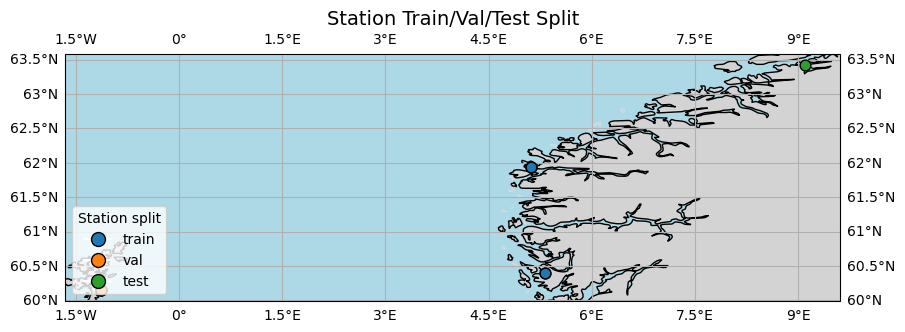

In [ ]:
# pip install cartopy matplotlib

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Station metadata from dataset
stations = ds["station"].values
lats = ds["station_latitude"].values
lons = ds["station_longitude"].values

# Assign split labels
split_labels = []
for st in stations:
    if st in train_stn:
        split_labels.append("train")
    elif st in val_stn:
        split_labels.append("val")
    elif st in test_stn:
        split_labels.append("test")
    else:
        split_labels.append("unknown")

# Map colors
colors = {"train": "tab:blue", "val": "tab:orange", "test": "tab:green", "unknown": "gray"}

# Plot
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.gridlines(draw_labels=True)

# Scatter stations
for lat, lon, label in zip(lats, lons, split_labels):
    ax.scatter(lon, lat, color=colors[label], s=60, edgecolor="k", transform=ccrs.PlateCarree(), zorder=5)

# Legend
handles = [plt.Line2D([0], [0], marker="o", color="w", label=lbl,
                      markerfacecolor=col, markersize=10, markeredgecolor="k")
           for lbl, col in colors.items() if lbl != "unknown"]
ax.legend(handles=handles, loc="lower left", title="Station split")

plt.title("Station Train/Val/Test Split", fontsize=14)
plt.show()
